# AlphaLens SHAP and Error Analysis

This notebook explains the selected XGBoost model on its untouched test fold. It verifies SHAP additivity, examines global and event-level contributions, tests importance stability across source types and time, and locates the model's largest errors. SHAP explains model behavior, not economic causality.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import shap
from IPython.display import display

ROOT = Path.cwd()
if ROOT.name == 'notebooks':
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from pipelines.ml.features import build_event_feature_dataset
from pipelines.ml.interpretability import analyze_experiment
from pipelines.ml.xgboost_model import run_xgboost_experiment

sns.set_theme(style='whitegrid', context='notebook')
pd.set_option('display.max_columns', 30)

c:\Users\Lixing\Desktop\alphalens\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Explain the locked test fold

In [2]:
dataset = build_event_feature_dataset(horizon=30, include_topics=True)
experiment = run_xgboost_experiment(dataset)
report = analyze_experiment(experiment)
display(pd.Series(report.additivity, name='value'))

rows                       151
max_absolute_error         0.0
mean_absolute_error        0.0
tolerance              0.00001
passed                    True
Name: value, dtype: object

## Global model drivers

Mean absolute SHAP measures how strongly a feature moved predictions on average. Mean signed SHAP indicates net direction over this test sample.

,feature,mean_abs_shap,mean_shap,shap_std,nonzero_share,rank
0,sentiment_change_from_prior,0.001804,0.000450,0.001874,1.0,1
1,sma_ratio_50d,0.001799,0.001799,0.002023,1.0,2
2,momentum_63d,0.001629,-0.000408,0.002043,1.0,3
3,momentum_5d,0.001391,-0.000504,0.001589,1.0,4
4,sma_ratio_20d,0.001102,0.000076,0.001638,1.0,5
5,event_month_cos,0.001082,0.000013,0.001389,1.0,6
6,topic_margins_profitability_sentiment,0.001070,0.000233,0.001141,1.0,7
7,beta_63d,0.000990,-0.000257,0.001313,1.0,8
8,volatility_21d,0.000883,-0.000318,0.002173,1.0,9
9,days_since_prior_source_event,0.000819,0.000220,0.001200,1.0,10


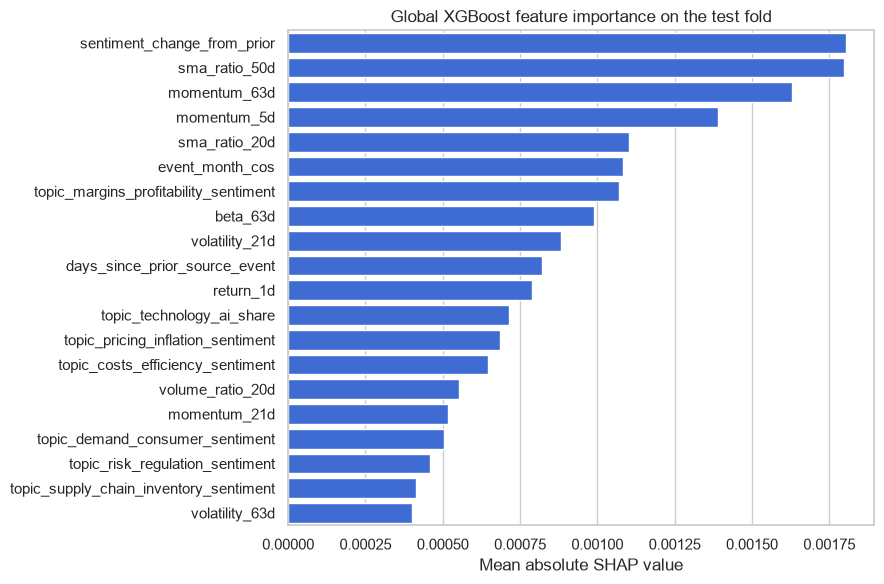

In [3]:
top_global = report.global_importance.head(20)
display(top_global)
fig, ax = plt.subplots(figsize=(9, 6))
sns.barplot(data=top_global, x='mean_abs_shap', y='feature', color='#2563eb', ax=ax)
ax.set(title='Global XGBoost feature importance on the test fold', xlabel='Mean absolute SHAP value', ylabel='')
plt.tight_layout()
plt.show()

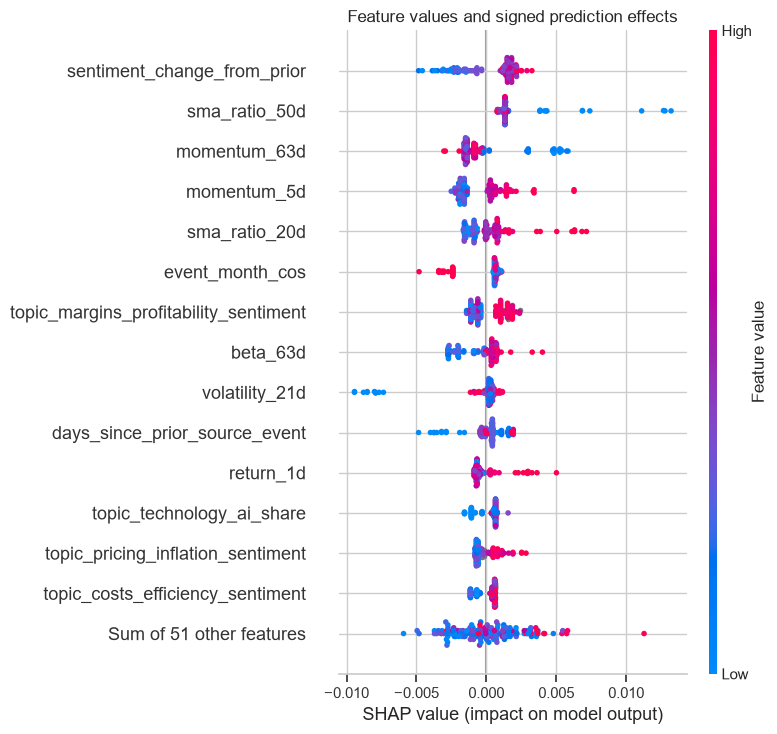

In [4]:
shap.plots.beeswarm(report.explanation, max_display=15, show=False)
plt.title('Feature values and signed prediction effects')
plt.tight_layout()
plt.show()

## Importance stability

,group_type,left_group,right_group,features,importance_spearman,top_n,top_overlap,top_jaccard
0,event_source,earnings_call,sec_filing,65,0.975123,10,9,0.818182
1,test_half,early,late,65,0.993689,10,9,0.818182


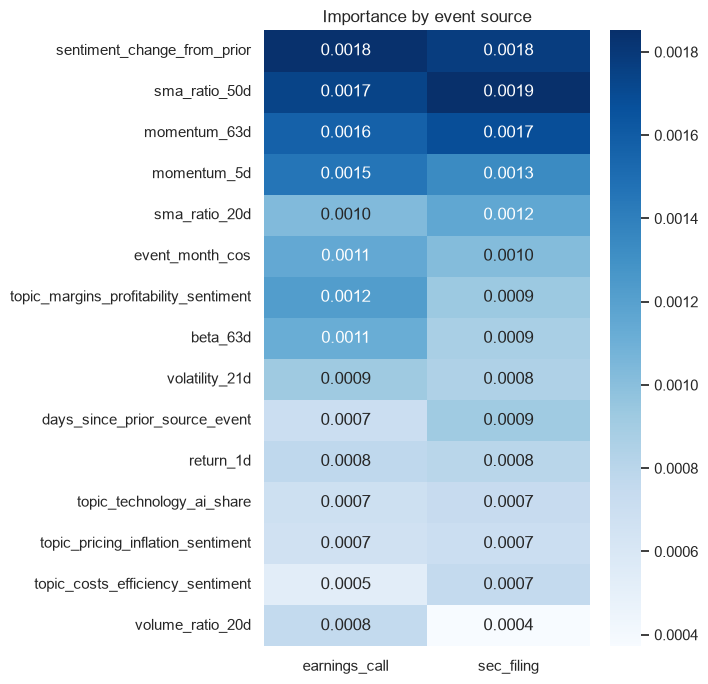

In [5]:
display(report.stability)
top_features = report.global_importance.head(15)['feature']
source_importance = report.group_importance.loc[
    (report.group_importance['group_type'] == 'event_source')
    & report.group_importance['feature'].isin(top_features)
].pivot(index='feature', columns='group_value', values='mean_abs_shap')
source_importance = source_importance.reindex(top_features)
fig, ax = plt.subplots(figsize=(7, 7))
sns.heatmap(source_importance, annot=True, fmt='.4f', cmap='Blues', ax=ax)
ax.set(title='Importance by event source', xlabel='', ylabel='')
plt.tight_layout()
plt.show()

## Where the model fails

,slice_type,slice_value,rows,mae,rmse,directional_accuracy,mean_prediction,mean_actual,prediction_bias
0,event_source,earnings_call,71,0.064883,0.085414,0.563380,0.006604,-0.001326,0.007930
1,event_source,sec_filing,80,0.061364,0.081476,0.487500,0.001720,0.005981,-0.004261
2,overall,all,151,0.063018,0.083351,0.523179,0.004017,0.002545,0.001471


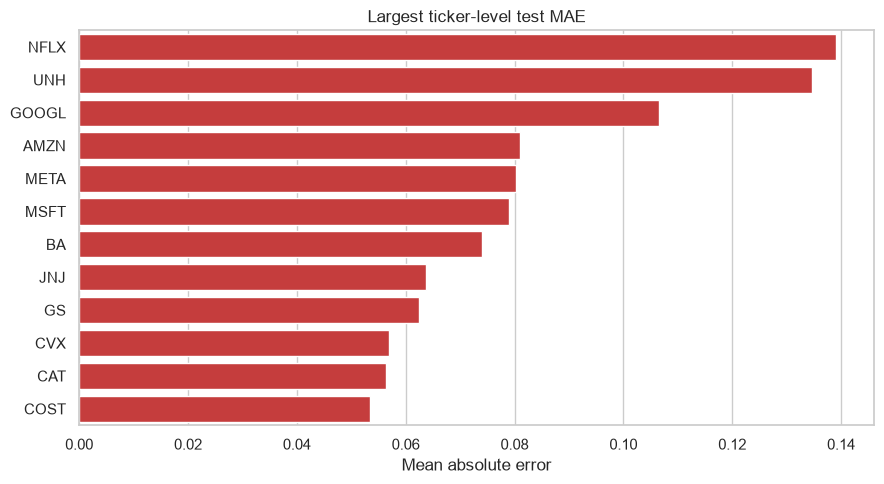

In [6]:
display(report.error_slices.loc[report.error_slices['slice_type'].isin(['overall', 'event_source'])])
ticker_errors = report.error_slices.loc[report.error_slices['slice_type'] == 'ticker'].nlargest(12, 'mae')
fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(data=ticker_errors, x='mae', y='slice_value', color='#dc2626', ax=ax)
ax.set(title='Largest ticker-level test MAE', xlabel='Mean absolute error', ylabel='')
plt.tight_layout()
plt.show()

,event_key,ticker,event_source,event_date,feature_as_of_date,excess_return_30d,prediction,residual,absolute_error,direction_correct
0,sec_filing:0000731766-25-000236,UNH,sec_filing,2025-08-11,2025-08-12,0.321982,0.003883,0.318099,0.318099,True
1,earnings_call:220,UNH,earnings_call,2025-07-29,2025-07-30,0.292642,0.014536,0.278106,0.278106,True
2,sec_filing:0001065280-26-000138,NFLX,sec_filing,2026-04-17,2026-04-20,-0.193019,0.006959,-0.199978,0.199978,False
3,earnings_call:64,GOOGL,earnings_call,2025-07-23,2025-07-24,0.202668,0.007238,0.195430,0.195430,True
4,sec_filing:0001652044-25-000062,GOOGL,sec_filing,2025-07-24,2025-07-25,0.194185,0.004747,0.189438,0.189438,True
5,earnings_call:236,CVX,earnings_call,2026-01-30,2026-02-02,0.184094,0.000859,0.183235,0.183235,True
6,earnings_call:132,NFLX,earnings_call,2026-04-16,2026-04-17,-0.185923,-0.004194,-0.181730,0.181730,True
7,sec_filing:0000886982-26-000118,GS,sec_filing,2026-05-01,2026-05-04,0.167777,-0.004192,0.171969,0.171969,False
8,earnings_call:80,META,earnings_call,2026-01-28,2026-01-29,-0.123017,0.027021,-0.150038,0.150038,False
9,earnings_call:133,NFLX,earnings_call,2026-01-20,2026-01-21,0.167753,0.020331,0.147422,0.147422,True


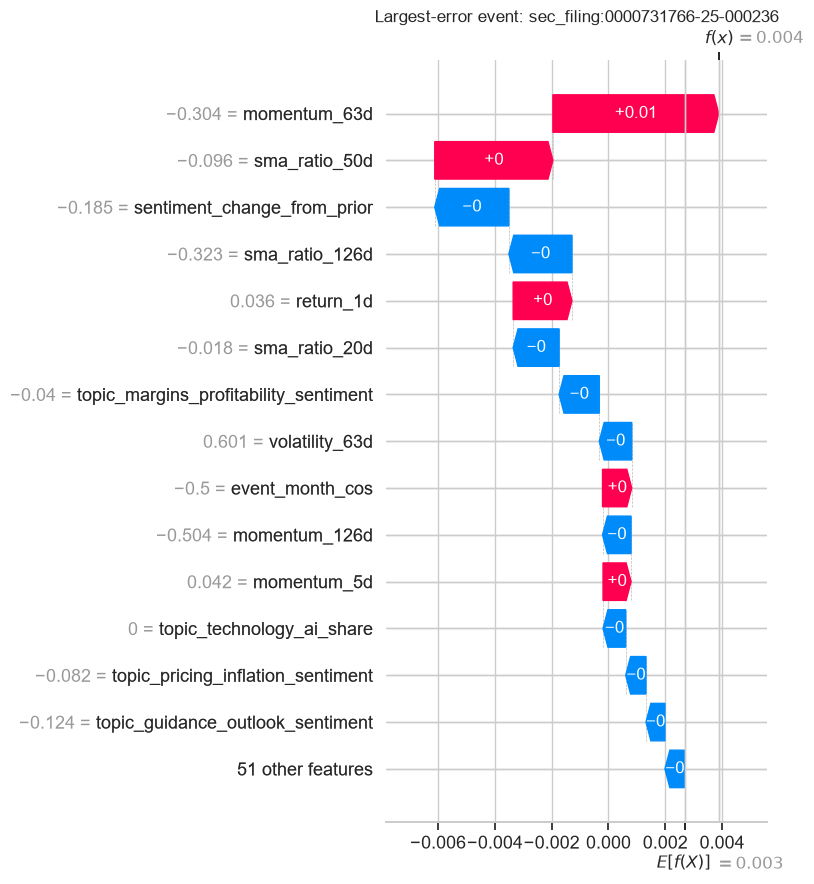

In [7]:
worst_events = report.errors.head(15)
display(worst_events)
worst_key = worst_events.iloc[0]['event_key']
test_frame = experiment.split.test.reset_index(drop=True)
worst_position = test_frame.index[test_frame['event_key'] == worst_key][0]
shap.plots.waterfall(report.explanation[worst_position], max_display=15, show=False)
plt.title(f'Largest-error event: {worst_key}')
plt.tight_layout()
plt.show()

In [8]:
display(report.local_contributions.loc[report.local_contributions['event_key'] == worst_key])

,event_key,ticker,event_source,feature_as_of_date,prediction,actual,base_value,local_rank,feature,feature_value,shap_value,effect
155,sec_filing:0000731766-25-000236,UNH,sec_filing,2025-08-12,0.003883,0.321982,0.002676,1,momentum_63d,-0.304484,0.005841,raises_prediction
156,sec_filing:0000731766-25-000236,UNH,sec_filing,2025-08-12,0.003883,0.321982,0.002676,2,sma_ratio_50d,-0.096171,0.004160,raises_prediction
157,sec_filing:0000731766-25-000236,UNH,sec_filing,2025-08-12,0.003883,0.321982,0.002676,3,sentiment_change_from_prior,-0.184590,-0.002609,lowers_prediction
158,sec_filing:0000731766-25-000236,UNH,sec_filing,2025-08-12,0.003883,0.321982,0.002676,4,sma_ratio_126d,-0.322731,-0.002222,lowers_prediction
159,sec_filing:0000731766-25-000236,UNH,sec_filing,2025-08-12,0.003883,0.321982,0.002676,5,return_1d,0.036454,0.002071,raises_prediction


## Interpretation discipline

Stable SHAP rankings mean the model used similar rules across these slices; they do not mean those rules predicted returns well. The untouched metrics and backtest remain the decision criteria. Error slices are diagnostic hypotheses for future data collection, not permission to tune repeatedly against this test period.